## data preparation

In [ ]:
# load required libraries
#!pip install shapely scikit-learn shap rasterio -q
import geopandas as gpd
import rasterio
import numpy as np
import pandas as pd
from rasterio.mask import mask
from shapely.geometry import Point
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score
import shap
import matplotlib.pyplot as plt

# mount drive
# from google.colab import drive
# drive.mount('/content/drive')

# load the biomass training shapefile
biomass_gdf = gpd.read_file("/content/drive/MyDrive/GEE_Exports/Biomass_Sampled_5k_gr_final.shp") # includes tree and shrub - we will only be using the tree band

# define raster paths for feature set
landsat_path = "/content/drive/MyDrive/biomass_research/L8_Composite_2023_mosaic.tif"
et_path = "/content/drive/MyDrive/biomass_research/ET_2023.tif"
terrain_path = "/content/drive/MyDrive/GEE_Exports/terrain_30m.tif"
chm_path = '/content/drive/MyDrive/biomass_research/reprojected_CHM.tif'
soil_path = '/content/drive/MyDrive/biomass_research/soils_mosaic.tif'

In [ ]:
# our first task is to create a gdf that assigns feature values to each biomass point so we can train/test our model
def extract_raster_values(raster_path, gdf, band_names=None):
    """extracts raster values at point locations and adds them to the geodataframe, avoiding duplicate columns."""
    with rasterio.open(raster_path) as src:
        coords = [(x, y) for x, y in zip(gdf.geometry.x, gdf.geometry.y)]
        values = np.array([v for v in src.sample(coords)])

        # handle NoData (255.0 for CHM) - replace with NaN
        nodata = src.nodata
        if nodata is not None:
            values = np.where(values == nodata, np.nan, values)

        if band_names is None:
            band_names = [f'band_{i+1}' for i in range(values.shape[1])]

        df = pd.DataFrame(values, columns=band_names)

        # drop existing columns to prevent duplicates
        gdf = gdf.drop(columns=[col for col in band_names if col in gdf.columns], errors="ignore")

        return pd.concat([gdf.reset_index(drop=True), df], axis=1)


# make sure both datasets are in same crs
target_crs = "EPSG:32614"  # UTM Zone 14N

# ensure crs is correct before extraction
biomass_gdf = biomass_gdf.to_crs(target_crs)

# extract values from feature rasters and name the bands for clarity
biomass_gdf = extract_raster_values(landsat_path, biomass_gdf,
                                    band_names=['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'EVI','SAVI', 'MSAVI', 'NDMI'])
biomass_gdf = extract_raster_values(et_path, biomass_gdf, band_names=['ET'])
biomass_gdf = extract_raster_values(terrain_path, biomass_gdf, band_names=['DEM', 'Slope', 'Aspect'])
biomass_gdf = extract_raster_values(soil_path, biomass_gdf, band_names=['bd','clay', 'ksat', 'n', 'om', 'ph', 'sand', 'silt', 'theta_r', 'theta_s', 'lambda', 'hb', 'alpha'])

with rasterio.open(chm_path) as src:
    chm_array = src.read(1)
    print("CHM dtype:", chm_array.dtype)
    print("CHM min/max:", chm_array.min(), chm_array.max())

biomass_gdf = extract_raster_values(chm_path, biomass_gdf, band_names=['CHM'])

# check if extraction worked
print("First few extracted values:\n", biomass_gdf[['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'ET', 'DEM', 'Slope', 'Aspect', 'CHM', 'om', 'sand']].head())

# save to csv for later use
biomass_gdf.to_csv("/content/drive/MyDrive/biomass_research/biomass_gdf_extracted_chm_swir", index=False)

CHM dtype: float32
CHM min/max: 0.0 255.0
First few extracted values:
        Blue     Green       Red       NIR     SWIR1     ET         DEM  Slope  \
0  0.299832  0.342430  0.381012  0.508062  0.589683  466.0  693.004944    1.0   
1  0.312317  0.357253  0.390445  0.512490  0.610528  496.0  753.708191    4.0   
2  0.273488  0.310255  0.328405  0.465658  0.508255  865.0  760.292664    5.0   
3  0.263202  0.289781  0.303407  0.444551  0.490930  681.0  683.951660    1.0   
4  0.271906  0.312840  0.331925  0.484522  0.533816  866.0  685.617065   22.0   

   Aspect  CHM        om       sand  
0   105.0  5.0  0.302826  13.190499  
1   339.0  3.0  0.631992  40.067650  
2   216.0  4.0  0.632674  40.067650  
3   267.0  4.0  0.675936  40.067650  
4   115.0  6.0  0.653694  40.067650  


## model set up

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# read in our gdf from earlier
biomass_gdf = pd.read_csv("/content/drive/MyDrive/biomass_research/biomass_gdf_extracted_chm_swir")

# drop rows with missing values (due to extraction issues)
print("Before dropna:", len(biomass_gdf))
print("Missing values by column:\n", biomass_gdf.isna().sum())
biomass_gdf = biomass_gdf.dropna()
print("After dropna:", len(biomass_gdf))

# drop non-numeric columns and target variables
# define features
X = biomass_gdf.drop(columns=["treeBiomas", "shrubBioma", "geometry"])

# keep only numeric columns
X = X.select_dtypes(include=np.number)
y = biomass_gdf["treeBiomas"]  # specify the tree band as our target variable

# split dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Before dropna: 5000
Missing values by column:
 shrubBioma    0
treeBiomas    0
geometry      0
Blue          0
Green         0
Red           0
NIR           0
SWIR1         0
SWIR2         0
NDVI          0
EVI           0
SAVI          0
MSAVI         0
NDMI          0
ET            0
DEM           0
Slope         0
Aspect        0
bd            0
clay          0
ksat          0
n             0
om            0
ph            0
sand          0
silt          0
theta_r       0
theta_s       0
lambda        0
hb            0
alpha         0
CHM           1
dtype: int64
After dropna: 4999


In [ ]:
# preview
X_train.head()

,Blue,Green,Red,NIR,SWIR1,SWIR2,NDVI,EVI,SAVI,MSAVI,...,om,ph,sand,silt,theta_r,theta_s,lambda,hb,alpha,CHM
1739,0.256713,0.284405,0.295212,0.445692,0.466345,0.376007,0.203103,0.291261,0.181899,0.175385,...,0.153895,8.024285,40.773170,31.933594,0.073548,0.491718,0.305782,0.498858,-0.494325,4.0
4944,0.271838,0.297935,0.316525,0.427982,0.512930,0.431915,0.149706,0.216279,0.134339,0.129085,...,0.670887,7.732564,40.067650,45.733856,0.063308,0.507025,0.318776,0.314180,-0.322522,5.0
2917,0.254018,0.284708,0.311905,0.413243,0.512957,0.420530,0.139747,0.183643,0.124072,0.118675,...,-0.101641,6.638805,61.383900,30.500000,0.039610,0.471418,0.374122,0.180660,-0.176215,4.0
1595,0.247720,0.273763,0.289905,0.448717,0.459140,0.385138,0.215012,0.298464,0.192326,0.185540,...,0.180580,7.420678,40.356304,33.766144,0.061195,0.486482,0.316967,0.271357,-0.277048,6.0
3215,0.269005,0.299393,0.320842,0.446435,0.497393,0.409255,0.163686,0.231900,0.148656,0.143594,...,0.671092,7.734360,40.067650,45.762695,0.063308,0.507025,0.318776,0.314180,-0.322522,4.0


## random forest implementation

In [ ]:
# load libraries
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import shap
import numpy as np

# define RF model from sklearn
rf = RandomForestRegressor(random_state=42)

# define hyperparameter distributions
param_dist = {
    'n_estimators': [200, 500, 1000, 1500, 2000],       # preliminary runs identified 1,000 as ideal so we will test around that value
    'max_depth': [None] + list(np.arange(10, 101, 10)),  # None or 10–100
    'min_samples_split': np.arange(2, 21, 2),        # 2–20
    'min_samples_leaf': np.arange(1, 11, 1),         # 1–10
    'max_features': ['sqrt', 'log2', None, 0.3, 0.5]         # common feature selection options
}

# perform Randomized Search with 5-fold cross validation
random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=50,              # try 50 random combinations
    cv=5,
    scoring='r2',
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

# get best model
best_rf = random_search.best_estimator_

# make predictions
y_pred = best_rf.predict(X_test)

# evaluate model
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"Best Parameters: {random_search.best_params_}")
print(f"Test R² Score: {r2:.4f}")
print(f"Test RMSE: {rmse:.4f}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'n_estimators': 1500, 'min_samples_split': np.int64(4), 'min_samples_leaf': np.int64(4), 'max_features': 'log2', 'max_depth': np.int64(100)}
Test R² Score: 0.6283
Test RMSE: 6100.2721


In [ ]:
# save the rf model to drive for later reference
import joblib

joblib.dump(best_rf, '/content/drive/MyDrive/biomass_research/best_rf_model.pkl')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved to Google Drive!


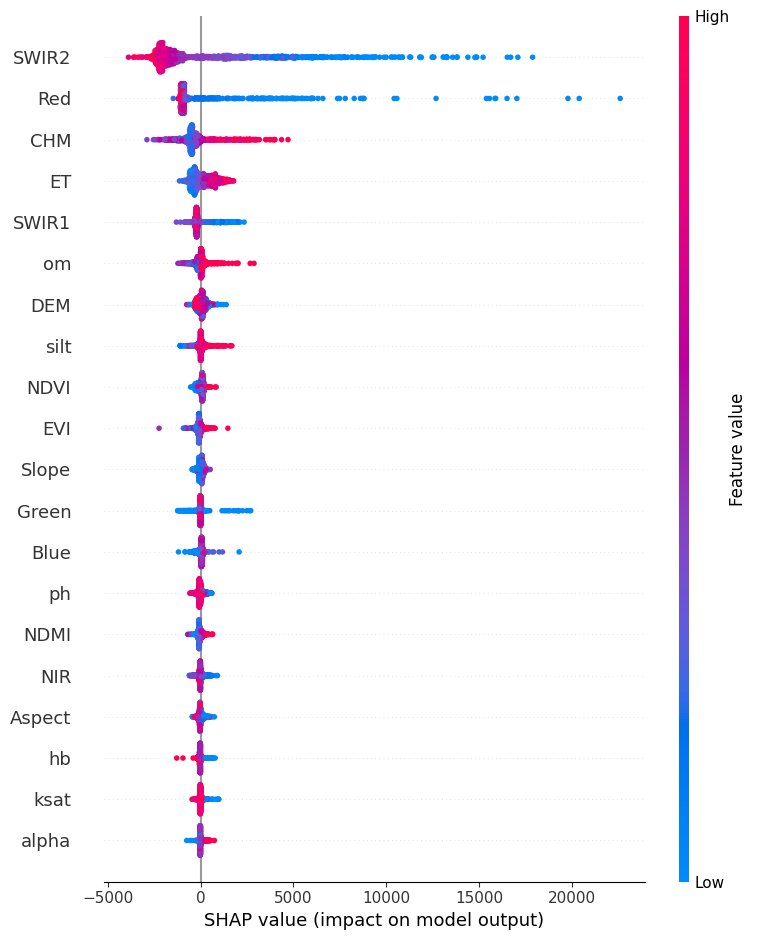

In [ ]:
# run shap to get feature importance values
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

# plot results
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

## apply model to whole raster stack

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window
from rasterio.warp import Resampling
from tqdm import tqdm

## ----------- set up parameters ------------
# define output path for full prediction raster
# due to memory limitations in Colab, we will split our rasters into tiles to make predictions one tile at a time
output_dir = "/content/drive/MyDrive/biomass_research/biomass_tiles_rf_masked_final_2"
os.makedirs(output_dir, exist_ok=True)

# load saved RF model from earlier
model = joblib.load("/content/drive/MyDrive/biomass_research/best_rf_model.pkl")

final_output = "/content/drive/MyDrive/biomass_research/tree_biomass_prediction_rf_tiled_masked_final_2.tif"
tile_size = 512  # or smaller if RAM is a concern

# define rasters and bands again, for clarity
rasters = {
    "landsat": ("/content/drive/MyDrive/biomass_research/L8_Composite_2023_mosaic.tif",
                ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'EVI','SAVI', 'MSAVI', 'NDMI']),
    "et": ("/content/drive/MyDrive/biomass_research/ET_2023.tif",
           ['ET']),
    "terrain": ("/content/drive/MyDrive/GEE_Exports/terrain_30m.tif",
                ['DEM', 'Slope', 'Aspect']),
    "soil": ("/content/drive/MyDrive/biomass_research/soils_mosaic.tif",
             ['bd','clay', 'ksat', 'n', 'om', 'ph', 'sand', 'silt', 'theta_r', 'theta_s', 'lambda', 'hb', 'alpha']),
    "chm": ("/content/drive/MyDrive/biomass_research/reprojected_CHM_aligned.tif",
            ['CHM']),
}

# create feature names list to make sure we didn't lose anything
feature_names = []
for key, (path, bands) in rasters.items():
    feature_names.extend(bands)

print(f"Feature order: {feature_names}")
print(f"Total features: {len(feature_names)}")

# get raster dimensions from reference raster
with rasterio.open(rasters["landsat"][0]) as ref:
    width, height = ref.width, ref.height
    profile = ref.profile
    profile.update(dtype=rasterio.float32, count=1)

# define tile size
total_tiles = ((height + tile_size - 1) // tile_size) * ((width + tile_size - 1) // tile_size)
tile_count = 0

# load forest mask, since training was only on woody plants
forest_mask_path = '/content/drive/MyDrive/GEE_Exports/forestMask_32614.tif'

## ------------- begin making predictions on each tile -------------
for y in tqdm(range(0, height, tile_size), desc="Rows"):
    for x in range(0, width, tile_size):
        tile_filename = os.path.join(output_dir, f"tile_{x}_{y}.tif")
        window = Window(x, y, min(tile_size, width - x), min(tile_size, height - y))
        tile_data = []
        valid = True

        # read data for current tile from all raster sources
        for key, (path, bands) in rasters.items():
            with rasterio.open(path) as src:
                try:
                    arr = src.read(window=window, out_shape=(src.count, window.height, window.width),
                                   resampling=Resampling.bilinear)
                except:
                    valid = False
                    break
                tile_data.append(arr)

        if not valid:
            print(f"Skipping tile x={x}, y={y} due to read error")
            tile_count += 1
            continue

        # read forest mask for current tile
        with rasterio.open(forest_mask_path) as mask_src:
            try:
                forest_mask_tile = mask_src.read(1, window=window,
                                                 out_shape=(window.height, window.width),
                                                 resampling=Resampling.nearest)  # use nearest for categorical mask
            except:
                print(f"Skipping tile x={x}, y={y} due to mask read error")
                tile_count += 1
                continue

        # stack and reshape data
        stacked = np.concatenate(tile_data, axis=0)
        flat = stacked.reshape(stacked.shape[0], -1).T  # (pixels, features)

        # create combined mask: pixel must have valid data AND be forest
        valid_mask = ~np.isnan(flat).any(axis=1)
        forest_mask_flat = forest_mask_tile.flatten() == 1  # binary, where 0 = nonforest and 1 = forest
        combined_mask = valid_mask & forest_mask_flat

        # make predictions only for forest pixels
        preds = np.full(flat.shape[0], np.nan)
        if combined_mask.any():
          flat_df = pd.DataFrame(flat[combined_mask], columns=feature_names)

        # for BIOMASS prediction, use the mean across trees
          tree_preds = np.array([tree.predict(flat_df) for tree in model.estimators_])
          mean_preds = np.mean(tree_preds, axis=0)

          preds[combined_mask] = mean_preds  # this is your biomass map

        # reshape prediction back to tile shape
        pred_tile = preds.reshape(window.height, window.width).astype(np.float32)

        # save tile
        tile_profile = profile.copy()
        tile_profile.update(
            height=window.height,
            width=window.width,
            transform=rasterio.windows.transform(window, ref.transform)
        )

        with rasterio.open(tile_filename, 'w', **tile_profile) as dst:
            dst.write(pred_tile, 1)

        tile_count += 1

print(f"Finished predicting {tile_count}/{total_tiles} tiles")
print(f"Individual tiles saved to: {output_dir}")

## ------ mosaic tiles back together for export ----------
# get list of all tile files
tile_files = [os.path.join(output_dir, f) for f in os.listdir(output_dir) if f.endswith('.tif')]
tile_files.sort()  # ensure consistent ordering

# mosaic together
with rasterio.open(final_output, 'w', **profile) as dst:
    for tile_file in tqdm(tile_files, desc="Mosaicking"):
        with rasterio.open(tile_file) as src:
            # read tile data
            tile_data = src.read(1)
            # get window position from filename
            filename = os.path.basename(tile_file)
            x, y = map(int, filename.replace('tile_', '').replace('.tif', '').split('_'))
            window = Window(x, y, tile_data.shape[1], tile_data.shape[0])
            # write to final output
            dst.write(tile_data, 1, window=window)

print(f"Final mosaic saved to: {final_output}")

# # ----------- clean up individual tiles----------------
# # uncomment if you want to delete individual tiles after mosaicking
# import shutil
# shutil.rmtree(output_dir)
# print("Individual tiles cleaned up")

Feature order: ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'EVI', 'SAVI', 'MSAVI', 'NDMI', 'ET', 'DEM', 'Slope', 'Aspect', 'bd', 'clay', 'ksat', 'n', 'om', 'ph', 'sand', 'silt', 'theta_r', 'theta_s', 'lambda', 'hb', 'alpha', 'CHM']
Total features: 29
Starting tile-based RF prediction...


Rows: 100%|██████████| 23/23 [51:28<00:00, 134.29s/it]


Finished predicting 621/621 tiles.
Individual tiles saved to: /content/drive/MyDrive/biomass_research/biomass_tiles_rf_masked_final_2
Mosaicking tiles...


Mosaicking: 100%|██████████| 621/621 [01:00<00:00, 10.32it/s]


Final mosaic saved to: /content/drive/MyDrive/biomass_research/tree_biomass_prediction_rf_tiled_masked_final_2.tif
Individual tiles cleaned up.


## calculate uncertainty from model

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window
from rasterio.warp import Resampling
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")

## ----------- set up parameters ------------
## this part is the same as earlier, but we'll use std dev and variance instead of mean to assess uncertainty - could probably be built into the above code cell to save time
# define output path for full prediction raster
# due to memory limitations in Colab, we will split our rasters into tiles to make predictions one tile at a time
output_dir = "/content/drive/MyDrive/biomass_research/tree_biomass_stddev_tiled_masked"
os.makedirs(output_dir, exist_ok=True)

# load rf model again
model = joblib.load("/content/drive/MyDrive/biomass_research/best_rf_model.pkl")

final_output = "/content/drive/MyDrive/biomass_research/tree_biomass_stddev_tiled_masked.tif"
tile_size = 512  # or smaller if RAM is still a concern

# define rasters and bands again, for clarity
rasters = {
    "landsat": ("/content/drive/MyDrive/biomass_research/L8_Composite_2023_mosaic.tif",
                ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'EVI','SAVI', 'MSAVI', 'NDMI']),
    "et": ("/content/drive/MyDrive/biomass_research/ET_2023.tif",
           ['ET']),
    "terrain": ("/content/drive/MyDrive/GEE_Exports/terrain_30m.tif",
                ['DEM', 'Slope', 'Aspect']),
    "soil": ("/content/drive/MyDrive/biomass_research/soils_mosaic.tif",
             ['bd','clay', 'ksat', 'n', 'om', 'ph', 'sand', 'silt', 'theta_r', 'theta_s', 'lambda', 'hb', 'alpha']),
    "chm": ("/content/drive/MyDrive/biomass_research/reprojected_CHM_aligned.tif",
            ['CHM']),
}

# load forest mask, since training was only on woody plants
mask_path = "/content/drive/MyDrive/GEE_Exports/forestMask_32614.tif"
mask_src = rasterio.open(mask_path)

# create feature names list to make sure we didn't lose anything
feature_names = []
for key, (path, bands) in rasters.items():
    feature_names.extend(bands)

print(f"Feature order: {feature_names}")
print(f"Total features: {len(feature_names)}")

# get raster dimensions from reference raster
with rasterio.open(rasters["landsat"][0]) as ref:
    width, height = ref.width, ref.height
    profile = ref.profile
    profile.update(dtype=rasterio.float32, count=1)

## ------------- begin making predictions on each tile -------------
total_tiles = ((height + tile_size - 1) // tile_size) * ((width + tile_size - 1) // tile_size)
tile_count = 0

print("Starting tile-based variance prediction...")
for y in tqdm(range(0, height, tile_size), desc="Rows"):
    for x in range(0, width, tile_size):
        tile_filename = os.path.join(output_dir, f"tile_{x}_{y}.tif")

        # uncomment these lines if you want to skip existing tiles
        # if os.path.exists(tile_filename):
        #     tile_count += 1
        #     continue  # Skip if tile already exists

        window = Window(x, y, min(tile_size, width - x), min(tile_size, height - y))
        mask_tile = mask_src.read(1, window=window, out_shape=(window.height, window.width), resampling=Resampling.nearest)
        mask_flat = mask_tile.flatten()
        tile_data = []
        valid = True

        # read data for current tile from all raster sources
        for key, (path, bands) in rasters.items():
            with rasterio.open(path) as src:
                try:
                    arr = src.read(window=window, out_shape=(src.count, window.height, window.width),
                                   resampling=Resampling.bilinear)
                except:
                    valid = False
                    break
                tile_data.append(arr)

        if not valid:
            print(f"Skipping tile x={x}, y={y} due to read error")
            tile_count += 1
            continue

        # stack and reshape data
        stacked = np.concatenate(tile_data, axis=0)
        flat = stacked.reshape(stacked.shape[0], -1).T  # (pixels, features)
        valid_mask = (~np.isnan(flat).any(axis=1)) & (mask_flat > 0)

        # make predictions
        preds = np.full(flat.shape[0], np.nan)
        if valid_mask.any():
            # convert to DataFrame with feature names to match training
            flat_df = pd.DataFrame(flat[valid_mask], columns=feature_names)

            # get predictions from all trees
            tree_preds = np.array([tree.predict(flat_df) for tree in model.estimators_])  # shape: (n_trees, n_pixels)

            # compute variance across trees
            var_preds = np.var(tree_preds, axis=0)

            # compute standard deviation across trees
            std_preds = np.sqrt(var_preds)

            preds[valid_mask] = std_preds # or var_preds if you want variance instead

        # reshape prediction back to tile shape
        pred_tile = preds.reshape(window.height, window.width).astype(np.float32)

        # save intermediate tile
        tile_profile = profile.copy()
        tile_profile.update(
            height=window.height,
            width=window.width,
            transform=rasterio.windows.transform(window, ref.transform)
        )

        with rasterio.open(tile_filename, 'w', **tile_profile) as dst:
            dst.write(pred_tile, 1)

        tile_count += 1

print(f"Finished predicting {tile_count}/{total_tiles} variance tiles")
print(f"Individual variance tiles saved to: {output_dir}")

## ------ mosaic tiles back together for export ----------
# get list of all tile files
tile_files = [os.path.join(output_dir, f) for f in os.listdir(output_dir) if f.endswith('.tif')]
tile_files.sort()  # ensure consistent ordering

# mosaic together
with rasterio.open(final_output, 'w', **profile) as dst:
    for tile_file in tqdm(tile_files, desc="Mosaicking"):
        with rasterio.open(tile_file) as src:
            # read tile data
            tile_data = src.read(1)
            # get window position from filename
            filename = os.path.basename(tile_file)
            x, y = map(int, filename.replace('tile_', '').replace('.tif', '').split('_'))
            window = Window(x, y, tile_data.shape[1], tile_data.shape[0])
            # write to final output
            dst.write(tile_data, 1, window=window)

print(f"Final variance mosaic saved to: {final_output}")

# # ----------- clean up individual tiles----------------
# # uncomment if you want to delete individual tiles after mosaicking
# import shutil
# shutil.rmtree(output_dir)
# print("Individual tiles cleaned up")

Feature order: ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'EVI', 'SAVI', 'MSAVI', 'NDMI', 'ET', 'DEM', 'Slope', 'Aspect', 'bd', 'clay', 'ksat', 'n', 'om', 'ph', 'sand', 'silt', 'theta_r', 'theta_s', 'lambda', 'hb', 'alpha', 'CHM']
Total features: 29
Starting tile-based variance prediction...


Rows: 100%|██████████| 23/23 [50:26<00:00, 131.58s/it]


Finished predicting 621/621 variance tiles.
Individual variance tiles saved to: /content/drive/MyDrive/biomass_research/tree_biomass_variance_rf_masked
Mosaicking variance tiles...


Mosaicking: 100%|██████████| 621/621 [00:38<00:00, 16.22it/s]


Final variance mosaic saved to: /content/drive/MyDrive/biomass_research/tree_biomass_variance_tiled_masked.tif
Individual tiles cleaned up.


Class 1 pixels: 8377890, Class 2: 33240532, Class 3: 13248941


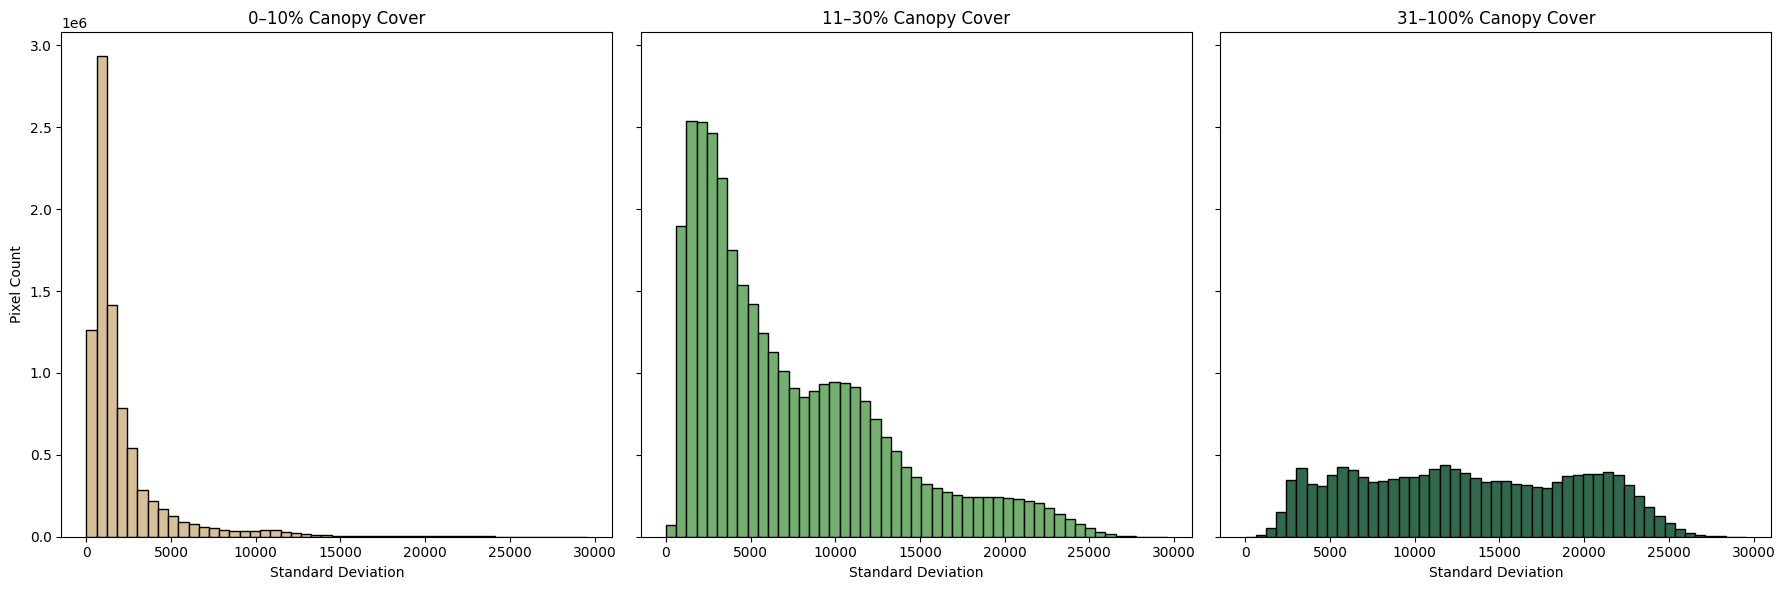

In [ ]:
 # load libraries
import rasterio
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from rasterio.features import geometry_mask

# load std dev raster
with rasterio.open("/content/drive/MyDrive/biomass_research/tree_biomass_stddev_tiled_masked.tif") as src:
    data = src.read(1)
    transform = src.transform
    crs = src.crs

# load canopy cover class shapefiles and reproject to raster std dev CRS
class1_shp = gpd.read_file('/content/drive/MyDrive/GEE_Exports/canopy_class_1_0-10pct.shp').to_crs(crs)
class2_shp = gpd.read_file('/content/drive/MyDrive/GEE_Exports/canopy_class_2_11-30pct.shp').to_crs(crs)
class3_shp = gpd.read_file('/content/drive/MyDrive/GEE_Exports/canopy_class_3_31-100pct.shp').to_crs(crs)

# create canopy cover class masks
def mask_from_shapefile(gdf, raster_shape, transform):
    return geometry_mask(gdf.geometry, transform=transform, invert=True, out_shape=raster_shape)

mask1 = mask_from_shapefile(class1_shp, data.shape, transform)
mask2 = mask_from_shapefile(class2_shp, data.shape, transform)
mask3 = mask_from_shapefile(class3_shp, data.shape, transform)

# extract SD values by class
vals_class1 = data[mask1 & ~np.isnan(data)]
vals_class2 = data[mask2 & ~np.isnan(data)]
vals_class3 = data[mask3 & ~np.isnan(data)]

print(f"Class 1 pixels: {len(vals_class1)}, Class 2: {len(vals_class2)}, Class 3: {len(vals_class3)}")

# plot histograms for each class
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
bins = np.linspace(0, np.nanmax(data), 50)

# grassland
axes[0].hist(vals_class1, bins=bins, color='#D7C097', edgecolor='black')
axes[0].set_title('0–10% Canopy Cover')
axes[0].set_xlabel('Standard Deviation')
axes[0].set_ylabel('Pixel Count')

# savanna
axes[1].hist(vals_class2, bins=bins, color='#73AF6F', edgecolor='black')
axes[1].set_title('11–30% Canopy Cover')
axes[1].set_xlabel('Standard Deviation')

# woodland
axes[2].hist(vals_class3, bins=bins, color='#31694E', edgecolor='black')
axes[2].set_title('31–100% Canopy Cover')
axes[2].set_xlabel('Standard Deviation')

plt.tight_layout()
plt.show()

## generate plots for predicted vs observed values for model + GEDI datasets

/tmp/ipython-input-767150405.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


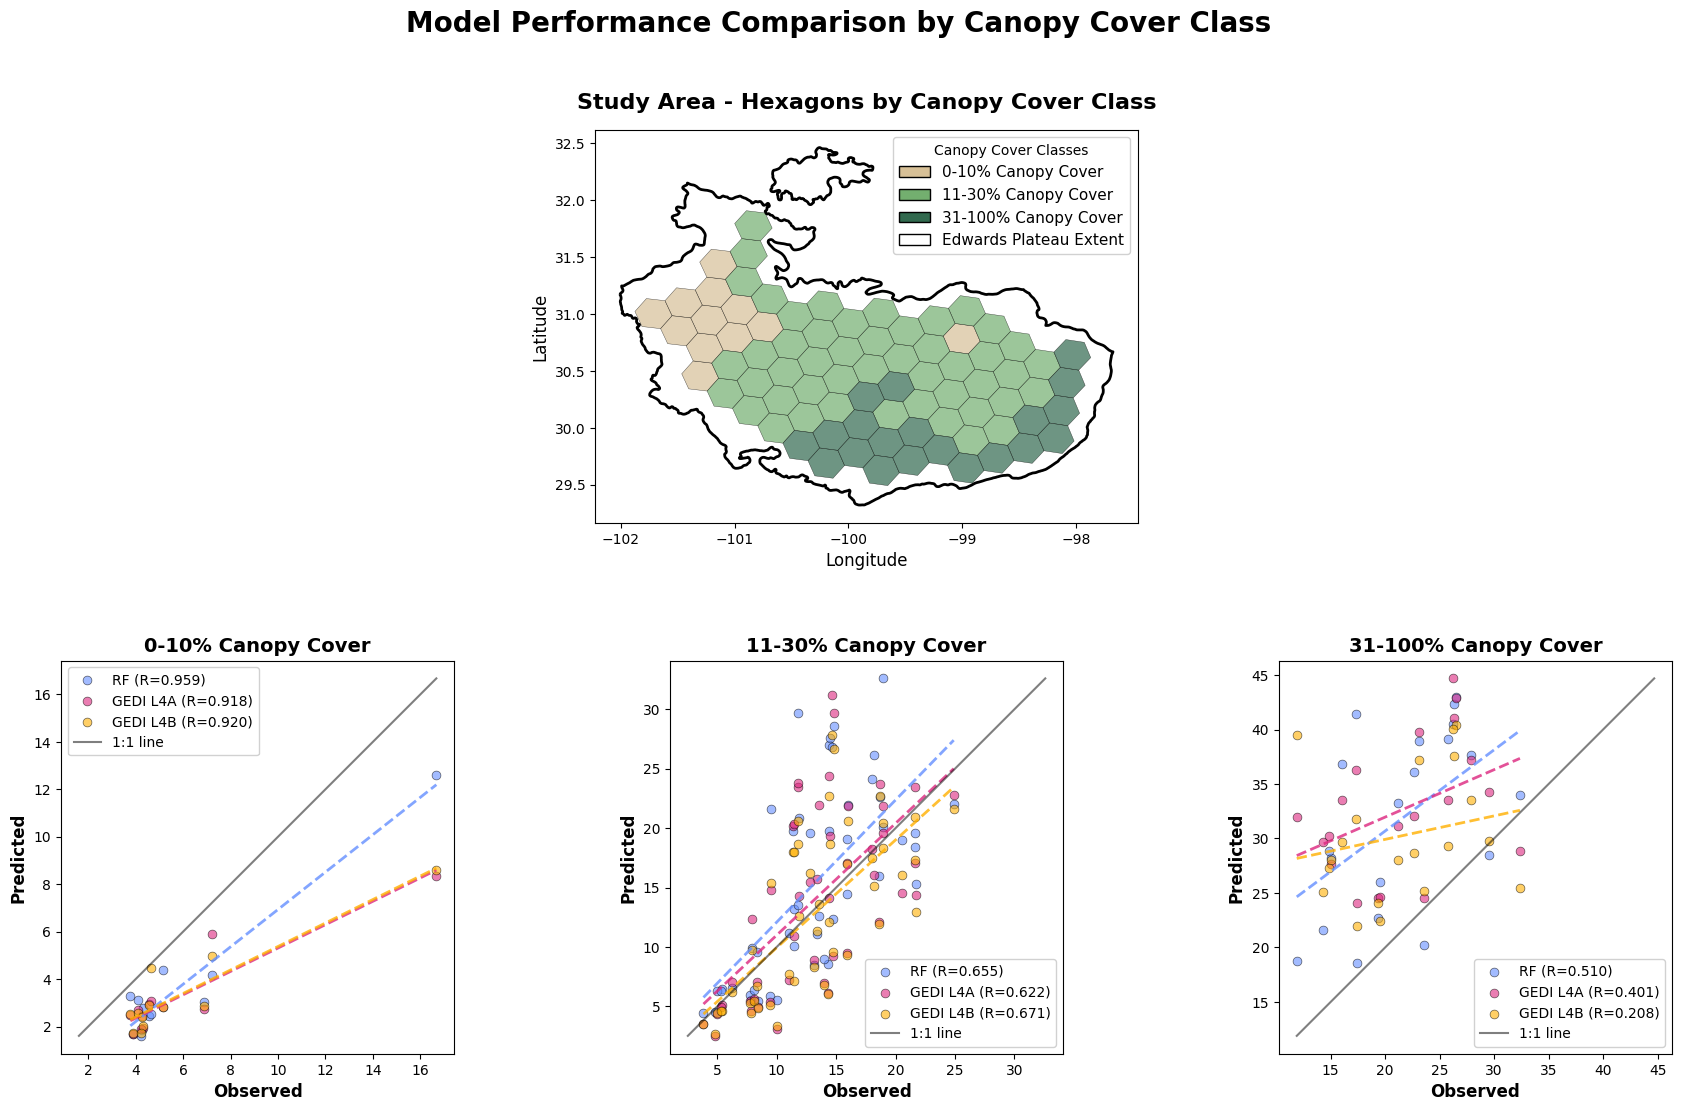


Model Performance Summary by Canopy Class

0-10% Canopy Cover
--------------------------------------------------------------------------------
Model                Pearson R    P-value      RMSE         MAE          N       
--------------------------------------------------------------------------------
RF                   0.9592       0.0000       2.4292       2.1741       12      
GEDI L4A             0.9184       0.0000       3.1850       2.5600       12      
GEDI L4B             0.9195       0.0000       3.1354       2.5042       12      


11-30% Canopy Cover
--------------------------------------------------------------------------------
Model                Pearson R    P-value      RMSE         MAE          N       
--------------------------------------------------------------------------------
RF                   0.6554       0.0000       6.3790       4.6707       48      
GEDI L4A             0.6222       0.0000       6.0520       4.6698       48      
GEDI L4B         

In [ ]:
# load libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy import stats
import geopandas as gpd

# load the CSV files from GEE
rf_data = pd.read_csv('/content/drive/MyDrive/GEE_Exports/RF_model_predicted_vs_observed.csv')
gedi_data = pd.read_csv('/content/drive/MyDrive/GEE_Exports/GEDI_model_predicted_vs_observed.csv')
gedi_l4b_data = pd.read_csv('/content/drive/MyDrive/GEE_Exports/GEDI_L4B_model_predicted_vs_observed.csv')

# load the canopy cover shapefiles
class1_shp = gpd.read_file('/content/drive/MyDrive/GEE_Exports/canopy_class_1_0-10pct.shp')
class2_shp = gpd.read_file('/content/drive/MyDrive/GEE_Exports/canopy_class_2_11-30pct.shp')
class3_shp = gpd.read_file('/content/drive/MyDrive/GEE_Exports/canopy_class_3_31-100pct.shp')

# load the study area outline
study_area = gpd.read_file('/content/drive/MyDrive/biomass_research/edwards_plateau_extent.geojson')

# define class labels and colors
class_labels = {
    1: '0-10% Canopy Cover',
    2: '11-30% Canopy Cover',
    3: '31-100% Canopy Cover'
}

class_colors = {
    1: '#D7C097',  # beige
    2: '#73AF6F',  # light green
    3: '#31694E'   # dark Green
}

# define model info (name, data, column, color)
models = [
    ('RF', rf_data, 'rf_mean', '#648FFF'),  # blue
    ('GEDI L4A', gedi_data, 'gedi_mean', '#DC267F'),  # pink
    ('GEDI L4B', gedi_l4b_data, 'l4b_mean', '#FFB000')  # gold
]

## ----------- create figure with map on top, three plots on bottom --------------
fig = plt.figure(figsize=(22, 12))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.25, height_ratios=[1, 1])

fig.suptitle('Model Performance Comparison by Canopy Cover Class',
             fontsize=20, fontweight='bold', y=0.98)

# top row: map spanning all three columns
ax_map = fig.add_subplot(gs[0, :])

# plot the study area outline first (as background)
study_area.boundary.plot(ax=ax_map, color='black', linewidth=2,
                         label='Edwards Plateau Extent')

# plot each canopy class
class1_shp.plot(ax=ax_map, color=class_colors[1], edgecolor='black',
                linewidth=0.3, alpha=0.7, label=class_labels[1])
class2_shp.plot(ax=ax_map, color=class_colors[2], edgecolor='black',
                linewidth=0.3, alpha=0.7, label=class_labels[2])
class3_shp.plot(ax=ax_map, color=class_colors[3], edgecolor='black',
                linewidth=0.3, alpha=0.7, label=class_labels[3])

ax_map.set_title('Study Area - Hexagons by Canopy Cover Class',
                 fontsize=16, fontweight='bold', pad=15)
ax_map.set_xlabel('Longitude', fontsize=12)
ax_map.set_ylabel('Latitude', fontsize=12)
ax_map.set_aspect('equal')

# create custom legend handles for canopy classes
legend_handles = [
    mpatches.Patch(facecolor=class_colors[1], edgecolor='black',
                   label=class_labels[1]),
    mpatches.Patch(facecolor=class_colors[2], edgecolor='black',
                   label=class_labels[2]),
    mpatches.Patch(facecolor=class_colors[3], edgecolor='black',
                   label=class_labels[3]),
    mpatches.Patch(facecolor='none', edgecolor='black',
                   label='Edwards Plateau Extent')
]

# add the legend to the map axis
ax_map.legend(handles=legend_handles,
              title='Canopy Cover Classes',
              loc='upper right', fontsize=11, framealpha=0.9)


# bottom row: three comparison plots
axes_plots = [fig.add_subplot(gs[1, i]) for i in range(3)]

for idx, canopy_class in enumerate([1, 2, 3]):
    ax = axes_plots[idx]

    # track min/max values for 1:1 line
    all_min = float('inf')
    all_max = float('-inf')

    # plot each model on the same axes
    for model_name, data, predicted_col, color in models:
        # filter data for this class
        class_data = data[data['canopy_class'] == canopy_class].dropna()

        if len(class_data) > 0:
            predicted = class_data[predicted_col]
            observed = class_data['CRM_LIVE']

            # calculate Pearson correlation
            r, p_value = stats.pearsonr(predicted, observed)

            # update min/max for 1:1 line
            all_min = min(all_min, observed.min(), predicted.min())
            all_max = max(all_max, observed.max(), predicted.max())

            # scatter plot
            ax.scatter(observed, predicted, alpha=0.6, s=40,
                      color=color, edgecolors='black', linewidth=0.5,
                      label=f'{model_name} (R={r:.3f})')

            # line of best fit
            z = np.polyfit(observed, predicted, 1)
            p = np.poly1d(z)
            x_line = np.linspace(observed.min(), observed.max(), 100)
            ax.plot(x_line, p(x_line), color=color, linestyle='--',
                   linewidth=2, alpha=0.8)

    # add 1:1 line
    if all_min != float('inf'):
        ax.plot([all_min, all_max], [all_min, all_max], 'k-',
               linewidth=1.5, alpha=0.5, label='1:1 line')

    # labels and title
    ax.set_xlabel('Observed', fontsize=12, fontweight='bold')
    ax.set_ylabel('Predicted', fontsize=12, fontweight='bold')
    ax.set_title(f'{class_labels[canopy_class]}', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10, framealpha=0.9)
   # ax.grid(True, alpha=0.3)

    # equal aspect ratio for better comparison
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

# print comprehensive summary stats
print(f"\n{'='*80}")
print(f"Model Performance Summary by Canopy Class")
print(f"{'='*80}")

for canopy_class in [1, 2, 3]:
    print(f"\n{class_labels[canopy_class]}")
    print(f"{'-'*80}")
    print(f"{'Model':<20} {'Pearson R':<12} {'P-value':<12} {'RMSE':<12} {'MAE':<12} {'N':<8}")
    print(f"{'-'*80}")

    for model_name, data, predicted_col, color in models:
        class_data = data[data['canopy_class'] == canopy_class].dropna()

        if len(class_data) > 0:
            predicted = class_data[predicted_col]
            observed = class_data['CRM_LIVE']
            r, p_value = stats.pearsonr(predicted, observed)
            rmse = np.sqrt(np.mean((predicted - observed)**2))
            mae = np.mean(np.abs(predicted - observed))

            print(f"{model_name:<20} {r:<12.4f} {p_value:<12.4f} {rmse:<12.4f} {mae:<12.4f} {len(class_data):<8}")
        else:
            print(f"{model_name:<20} {'No data':<12}")

    print()

## calculate global morans i

Loading raster data...
Raster shape: (3498, 4823) (rows, cols)
CRS: EPSG:4326
Resolution: (0.0008983152841195215, 0.0008983152841195215)
Valid sample points: 5000

Descriptive statistics:
count    5000.000000
mean        3.314193
std         4.947235
min        -6.210250
25%        -0.834023
50%         1.192378
75%         7.353770
max        23.586152
Name: value, dtype: float64

Creating spatial weights matrix (knn)...


/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


Neighbors per point (KNN): 16

Calculating Global Moran's I...

GLOBAL MORAN'S I RESULTS
Moran's I:               0.9832
Expected I:              -0.0002
Variance (normal):       0.000023
Z-score (normal):        203.3129
P-value (normal):        0.0000
P-value (permutation):   0.0010

Interpretation (based on p_sim): SIGNIFICANT POSITIVE spatial autocorrelation (clustering)


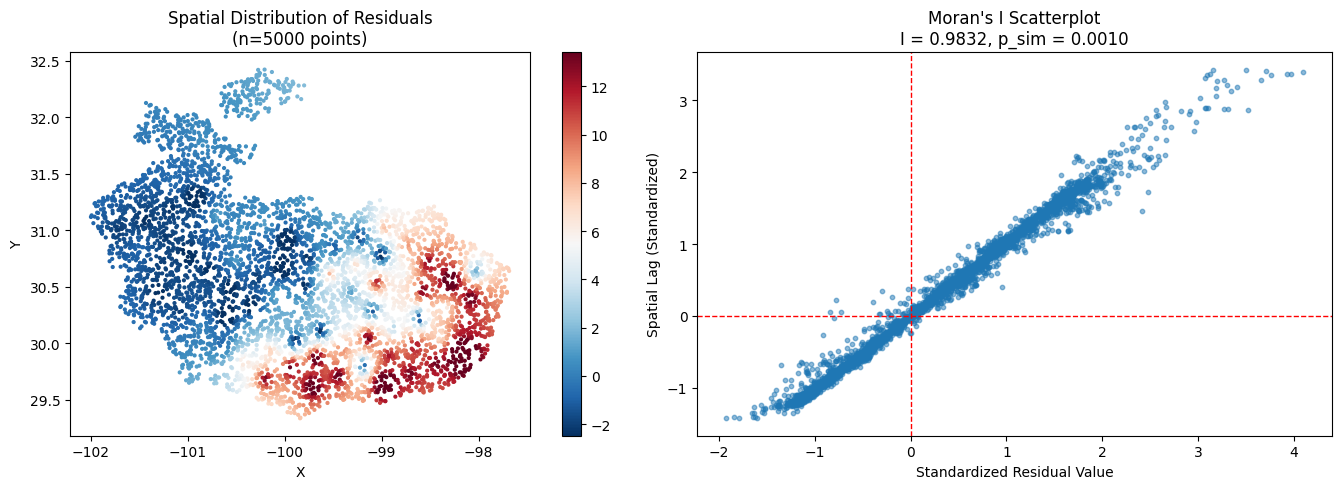

In [ ]:
# global moran's i calculation
# load libraries
#!pip install rasterio geopandas libpysal esda -q
import numpy as np
import rasterio
from rasterio.windows import Window
import geopandas as gpd
from shapely.geometry import Point
from libpysal.weights import DistanceBand, KNN
from esda.moran import Moran
import matplotlib.pyplot as plt

## ------- define parameters --------------
raster_path = '/content/drive/MyDrive/GEE_Exports/rf_residuals_toMoransI.tif'

# sampling strategy to manage memory:
# 'random'    -> random sample from full raster
# 'regular'   -> every Nth pixel in both row and column
# 'all'       -> read entire raster (only for small rasters)
# 'block_random' -> true memory-safe sampling using block windows
sampling_strategy = 'random'
sample_size = 5000       # number of pixels to sample for 'random' or 'block_random'
skip_pixels = 5          # stride for 'regular'

# spatial weights configuration
weights_type = 'knn'     # Options: 'knn' or 'distance'
k_neighbors = 16          # typical raster-like neighbor count (Queen ~8)
distance_threshold = 500 # meters, only used if weight_type == 'distance'
distance_style = 'binary' # 'binary' or 'inverse' (if 'distance' weights)

# islands handling (points with no neighbors under distance weights)
drop_islands = True      # drop islands if any; set False to keep

# Moran's I permutations
n_permutations = 999

# Random seed for reproducibility
rng_seed = 42

# ----------- define helper functions -------------------

def choose_utm_crs(geom_series: gpd.GeoSeries):
    """
    choose a suitable UTM CRS (EPSG) based on the mean lon/lat of the geometry and
    returns an EPSG integer
    """
    # ensure in geographic degrees
    if not geom_series.crs or not geom_series.crs.is_geographic:
        tmp = geom_series.to_crs(epsg=4326)
    else:
        tmp = geom_series

    # use centroid of all points for zone selection
    centroid = tmp.unary_union.centroid
    lon, lat = centroid.x, centroid.y

    zone = int(np.floor((lon + 180) / 6) + 1)
    if lat >= 0:
        epsg = 32600 + zone  # WGS84 / UTM Northern Hemisphere
    else:
        epsg = 32700 + zone  # WGS84 / UTM Southern Hemisphere
    return epsg

# load and sample raster

def load_raster_sample(raster_path, strategy='regular', sample_size=5000, skip=5, seed=42):
    """
    load raster with memory-efficient sampling strategies and
    returns a gdf with sampled points and 'value' attribute
    """
    rng = np.random.default_rng(seed)
    with rasterio.open(raster_path) as src:
        print(f"Raster shape: {src.shape} (rows, cols)")
        print(f"CRS: {src.crs}")
        print(f"Resolution: {src.res}")

        transform = src.transform
        crs = src.crs

        if strategy in ('random', 'regular', 'all'):
            # read band with nodata handling (masked -> fill with NaN)
            band = src.read(1, masked=True)
            data = np.ma.filled(band, np.nan)

        if strategy == 'all':
            rows, cols = np.where(~np.isnan(data))
            values = data[rows, cols]

        elif strategy == 'regular':
            rows = np.arange(0, data.shape[0], skip)
            cols = np.arange(0, data.shape[1], skip)
            row_grid, col_grid = np.meshgrid(rows, cols, indexing='ij')
            row_grid = row_grid.flatten()
            col_grid = col_grid.flatten()
            values = data[row_grid, col_grid]
            rows, cols = row_grid, col_grid

        elif strategy == 'random':
            valid_mask = ~np.isnan(data)
            valid_indices = np.argwhere(valid_mask)

            if len(valid_indices) > sample_size:
                sample_indices = rng.choice(len(valid_indices), size=sample_size, replace=False)
                sampled = valid_indices[sample_indices]
                rows, cols = sampled[:, 0], sampled[:, 1]
            else:
                rows, cols = valid_indices[:, 0], valid_indices[:, 1]

            values = data[rows, cols]

        elif strategy == 'block_random':
            # iterate block windows and sample a few per block
            pts = []
            vals = []
            for (idx, window) in src.block_windows(1):
                block = src.read(1, window=window, masked=True)
                block = np.ma.filled(block, np.nan)
                valid = ~np.isnan(block)
                if not valid.any():
                    continue

                r_idx, c_idx = np.where(valid)
                n = len(r_idx)
                take = min(n, max(1, sample_size // 20))  # sample a few per block
                choose = rng.choice(n, size=take, replace=False)
                r_sel, c_sel = r_idx[choose], c_idx[choose]

                # map window coords -> full raster coords
                rows_win = r_sel + window.row_off
                cols_win = c_sel + window.col_off

                xs, ys = rasterio.transform.xy(transform, rows_win, cols_win)
                pts.extend([Point(x, y) for x, y in zip(xs, ys)])
                vals.extend(block[r_sel, c_sel])

                if len(vals) >= sample_size:
                    break

            gdf = gpd.GeoDataFrame({'value': np.array(vals)}, geometry=pts, crs=crs)
            print(f"Valid sample points: {len(gdf)} (block_random)")
            return gdf

        else:
            raise ValueError(f"Unknown sampling strategy: {strategy}")

        # remove any residual NaNs
        valid_mask = ~np.isnan(values)
        rows, cols, values = rows[valid_mask], cols[valid_mask], values[valid_mask]

        print(f"Valid sample points: {len(values)}")

        xs, ys = rasterio.transform.xy(transform, rows, cols)
        geometry = [Point(x, y) for x, y in zip(xs, ys)]
        gdf = gpd.GeoDataFrame({'value': values}, geometry=geometry, crs=crs)
        return gdf

# load the data
gdf = load_raster_sample(
    raster_path,
    strategy=sampling_strategy,
    sample_size=sample_size,
    skip=skip_pixels,
    seed=rng_seed
)

print("\nDescriptive statistics:")
print(gdf['value'].describe())

# create spatial weights matrix

# coordinates in the current CRS
coords = np.column_stack([gdf.geometry.x, gdf.geometry.y])

if weights_type == 'distance':
    # ensure metric CRS (meters) for distance threshold
    if gdf.crs is None:
        raise ValueError("Raster CRS is none. A projected CRS in meters is required for distance weights.")

    is_geographic = False
    try:
        is_geographic = gdf.crs.is_geographic
    except Exception:
        pass

    if is_geographic:
        utm_epsg = choose_utm_crs(gdf.geometry)
        print(f"Reprojecting to metric CRS: EPSG:{utm_epsg} (UTM)")
        gdf = gdf.to_crs(epsg=utm_epsg)
        coords = np.column_stack([gdf.geometry.x, gdf.geometry.y])

    # build DistanceBand weights
    # start with binary connectivity; optionally convert to inverse-distance below
    w = DistanceBand(coords, threshold=distance_threshold, binary=True, silence_warnings=True)

    # handle islands (areas with no neighbors)
    if getattr(w, 'islands', []):
        print(f"Found {len(w.islands)} islands (no neighbors) at threshold={distance_threshold}")
        if drop_islands:
            keep_inds = np.setdiff1d(np.arange(len(coords)), w.islands)
            w = w.subset(keep_inds)
            gdf = gdf.iloc[keep_inds].reset_index(drop=True)
            coords = coords[keep_inds]
            print(f"Dropped islands; remaining points: {len(gdf)}")
        else:
            print("Consider increasing DISTANCE_THRESHOLD or enable DROP_ISLANDS=True")

    # optional: inverse-distance weights
    if distance_style == 'inverse':
        Wij = w.sparse.copy()
        # avoid division by zero (no zero distances should exist except self; DistanceBand excludes self)
        Wij.data = 1.0 / Wij.data
        w.sparse = Wij

    # row-standardize weights
    w.transform = 'r'

    avg_neighbors = np.mean(list(w.cardinalities.values()))
    print(f"Average neighbors per point: {avg_neighbors:.1f}")

elif weights_type == 'knn':
    w = KNN(coords, k=k_neighbors)
    w.transform = 'r'
    print(f"Neighbors per point (KNN): {k_neighbors}")

else:
    raise ValueError(f"Unknown WEIGHTS_TYPE: {weights_type}")

# ------------ calculate global moran's i -----------------------

y = gdf['value'].values
moran = Moran(y, w, permutations=n_permutations)

# print results
print("\n" + "="*60)
print("GLOBAL MORAN'S I RESULTS")
print("="*60)
print(f"Moran's I:               {moran.I:.4f}")
print(f"Expected I:              {moran.EI:.4f}")
print(f"Variance (normal):       {moran.VI_norm:.6f}")
print(f"Z-score (normal):        {moran.z_norm:.4f}")
print(f"P-value (normal):        {moran.p_norm:.4f}")
print(f"P-value (permutation):   {moran.p_sim:.4f}")
print("="*60)

# permutation p-value for inference
if moran.p_sim < 0.05:
    interpretation = ("SIGNIFICANT POSITIVE spatial autocorrelation (clustering)"
                      if moran.I > 0 else
                      "SIGNIFICANT NEGATIVE spatial autocorrelation (dispersion)")
else:
    interpretation = "NO significant spatial autocorrelation (random pattern)"
print(f"\nInterpretation (based on p_sim): {interpretation}")

# -------- visualization -------------------

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# spatial distribution of residuals
markersize = 4 if len(gdf) <= 10000 else 2
gdf.plot(
    column='value',
    cmap='RdBu_r',
    legend=True,
    ax=ax1,
    markersize=markersize,
    vmin=gdf['value'].quantile(0.02),
    vmax=gdf['value'].quantile(0.98)
)
ax1.set_title(f'Spatial Distribution of Residuals\n(n={len(gdf)} points)')
ax1.set_xlabel('X'); ax1.set_ylabel('Y')

# moran scatterplot
lag = w.sparse.dot(y)
y_std = y.std(ddof=0)
lag_std = lag.std(ddof=0)

if np.isclose(y_std, 0) or np.isclose(lag_std, 0):
    ax2.text(0.5, 0.5, "Near-zero variance; scatter unavailable.", ha='center')
else:
    standardized_values = (y - y.mean()) / y_std
    standardized_lag = (lag - lag.mean()) / lag_std
    ax2.scatter(standardized_values, standardized_lag, alpha=0.5, s=10)
    ax2.axhline(0, color='red', linestyle='--', linewidth=1)
    ax2.axvline(0, color='red', linestyle='--', linewidth=1)
    ax2.set_xlabel('Standardized Residual Value')
    ax2.set_ylabel('Spatial Lag (Standardized)')
    ax2.set_title(f"Moran's I Scatterplot\nI = {moran.I:.4f}, p_sim = {moran.p_sim:.4f}")

plt.tight_layout()
plt.savefig('morans_i_results.png', dpi=300, bbox_inches='tight')
plt.show()

## getis-ord * analysis

/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


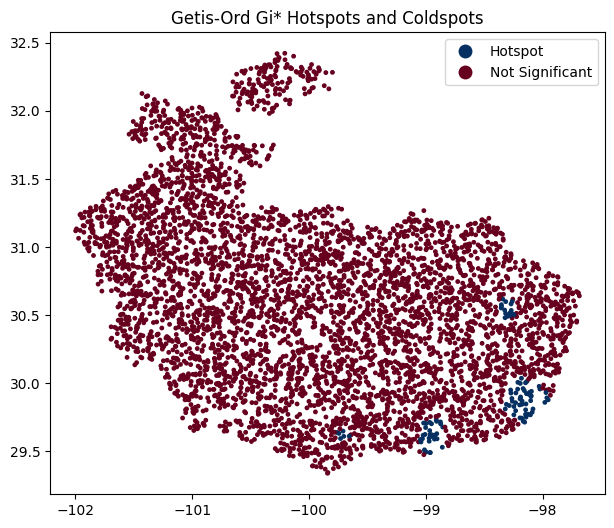


Getis-Ord Gi* summary:
Gi_category
Not Significant    4891
Hotspot             109
Name: count, dtype: int64

Interpretation: Hotspots detected; no coldspots.


In [ ]:
# load getis ord *
from esda.getisord import G_Local

# ensure coords and vals are from current gdf
coords = np.column_stack([gdf.geometry.x, gdf.geometry.y])
vals = gdf['value'].values

# create spatial weights (KNN)
w_gi = KNN(coords, k=16)
w_gi.transform = 'r'

# compute Gi* statistic
gi_star = G_Local(vals, w_gi)

# add Gi* z-scores to existing gdf
gdf['GiZ'] = gi_star.Zs

# classify hotspots/coldspots (95% confidence)
gdf['Gi_category'] = np.where(gdf['GiZ'] > 1.96, 'Hotspot',
                        np.where(gdf['GiZ'] < -1.96, 'Coldspot', 'Not Significant'))

# plot results
fig, ax = plt.subplots(figsize=(8, 6))
gdf.plot(column='Gi_category', categorical=True, legend=True,
         cmap='RdBu_r', ax=ax, markersize=6)
ax.set_title('Getis-Ord Gi* Hotspots and Coldspots')
plt.show()

# print summary and interpretation
print("\nGetis-Ord Gi* summary:")
print(gdf['Gi_category'].value_counts())

if 'Coldspot' in gdf['Gi_category'].values:
    print("\nInterpretation: Both hotspots and coldspots detected.")
elif 'Hotspot' in gdf['Gi_category'].values:
    print("\nInterpretation: Hotspots detected; no coldspots.")
else:
    print("\nInterpretation: No significant hotspots or coldspots.")